# EDA - Alojamientos Turísticos (StaySpain)

**Equipo:** Equip_34;
**Fecha:** 07/07/2026;
**Dataset:** raw_dataset_06_07_2026.csv

Este notebook cubre dos bloques:

1. **Visión general del dataset** (tipos, nulos, duplicados,
   estadísticas descriptivas básicas).
2. **Análisis específico** para las 3 preguntas de negocio del
   sprint (marketing, operaciones y experiencia del cliente).

Nota: los tratamientos aquí (parseo de fechas, columnas nuevas,
etc.) son solo para poder explorar los datos. La limpieza y
transformación "oficial" del dataset se documenta en las fases
correspondientes (Data Cleaning / Data Transformation) y no se
guarda desde este notebook.


## 1. Carga de datos e importación de librerías

In [1]:
# Librerías básicas para EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo simple para los gráficos
sns.set_style("whitegrid")


In [2]:
# Ruta del csv (ajustar si el archivo está en otra carpeta)
ruta_csv = "raw_dataset_06_07_2026.csv"

df = pd.read_csv(ruta_csv)

# Vista rápida de las primeras filas
df.head()


,apartment_id,name,description,host_id,neighbourhood_name,neighbourhood_district,room_type,accommodates,bathrooms,bedrooms,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,is_instant_bookable,reviews_per_month,country,city,insert_date
0,11964,A ROOM WITH A VIEW,Private bedroom in our attic apartment. Right ...,45553,Centro,NaN,Private room,2,2.0,1.0,...,100.0,100.0,100.0,100.0,100.0,FALSO,75.0,spain,malaga,31/07/2018
1,21853,Bright and airy room,We have a quiet and sunny room with a good vie...,83531,C�rmenes,Latina,Private room,1,1.0,1.0,...,90.0,100.0,100.0,80.0,90.0,FALSO,52.0,spain,madrid,10/01/2020
2,32347,Explore Cultural Sights from a Family-Friendly...,Open French doors and step onto a plant-filled...,139939,San Vicente,Casco Antiguo,Entire home/apt,4,1.0,2.0,...,100.0,100.0,100.0,100.0,100.0,VERDADERO,142.0,spain,sevilla,29/07/2019
3,35379,Double 02 CasanovaRooms Barcelona,Room at a my apartment. Kitchen and 2 bathroom...,152232,l'Antiga Esquerra de l'Eixample,Eixample,Private room,2,2.0,1.0,...,90.0,100.0,100.0,100.0,90.0,VERDADERO,306.0,spain,barcelona,10/01/2020
4,35801,Can Torras Farmhouse Studio Suite,Lay in bed & watch sunlight change the mood of...,153805,Quart,NaN,Private room,5,1.0,2.0,...,100.0,100.0,100.0,100.0,100.0,FALSO,39.0,spain,girona,19/02/2019


## 2. Visión general del dataset

In [3]:
# Dimensiones del dataset: filas x columnas
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])


Filas: 8000
Columnas: 35


In [4]:
# Tipos de datos de cada columna
df.dtypes


apartment_id                     int64
name                            object
description                     object
host_id                          int64
neighbourhood_name              object
neighbourhood_district          object
room_type                       object
accommodates                     int64
bathrooms                      float64
bedrooms                       float64
beds                           float64
amenities_list                  object
price                          float64
minimum_nights                   int64
maximum_nights                   int64
has_availability                object
availability_30                  int64
availability_60                  int64
availability_90                  int64
availability_365                 int64
number_of_reviews                int64
first_review_date               object
last_review_date                object
review_scores_rating           float64
review_scores_accuracy         float64
review_scores_cleanliness

Recordatorio (Data Understanding): `first_review_date`,
`last_review_date` e `insert_date` llegan como texto en
formato dd/mm/yyyy. Para poder graficarlas como fechas las
convertimos aquí solo para el EDA, sin sobrescribir el csv
original.


In [5]:
# Convertimos las fechas de texto a formato fecha (solo para EDA)
df["first_review_date"] = pd.to_datetime(
    df["first_review_date"], format="%d/%m/%Y", errors="coerce"
)
df["last_review_date"] = pd.to_datetime(
    df["last_review_date"], format="%d/%m/%Y", errors="coerce"
)


In [6]:
# Número de valores nulos por columna, ordenado de mayor a menor
nulos = df.isnull().sum().sort_values(ascending=False)
nulos[nulos > 0]


neighbourhood_district         3139
review_scores_value            1711
review_scores_location         1711
review_scores_checkin          1710
review_scores_accuracy         1705
review_scores_communication    1701
review_scores_cleanliness      1699
review_scores_rating           1696
last_review_date               1615
reviews_per_month              1614
first_review_date              1614
has_availability                550
price                           171
description                      54
bathrooms                        43
bedrooms                         39
amenities_list                   17
beds                              8
name                              3
dtype: int64

In [7]:
# Porcentaje de nulos sobre el total de filas
pct_nulos = (nulos[nulos > 0] / len(df) * 100).round(2)
pct_nulos


neighbourhood_district         39.24
review_scores_value            21.39
review_scores_location         21.39
review_scores_checkin          21.38
review_scores_accuracy         21.31
review_scores_communication    21.26
review_scores_cleanliness      21.24
review_scores_rating           21.20
last_review_date               20.19
reviews_per_month              20.18
first_review_date              20.18
has_availability                6.88
price                           2.14
description                     0.68
bathrooms                       0.54
bedrooms                        0.49
amenities_list                  0.21
beds                            0.10
name                            0.04
dtype: float64

`neighbourhood_district` sigue siendo el campo con más nulos
(alto porcentaje), y `has_availability` mantiene el bloque de
~550 nulos ya detectado en Data Understanding (pendiente de
revisión con IT).


In [8]:
# Duplicados: filas 100% idénticas
duplicados_totales = df.duplicated().sum()
print("Filas totalmente duplicadas:", duplicados_totales)

# Duplicados por apartment_id (mismo alojamiento, otra fila)
duplicados_id = df["apartment_id"].duplicated().sum()
print("apartment_id duplicados:", duplicados_id)


Filas totalmente duplicadas: 0
apartment_id duplicados: 307


In [9]:
# Estadísticas descriptivas de las variables numéricas clave
columnas_num = [
    "price", "accommodates", "bathrooms", "bedrooms", "beds",
    "minimum_nights", "maximum_nights", "number_of_reviews",
]
df[columnas_num].describe()


,price,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,number_of_reviews
count,7829.000000,8000.00000,7957.000000,7961.000000,7992.000000,8000.00000,8000.000000,8000.000000
mean,1007.751182,4.32700,1.598969,1.953147,2.971346,4.57125,761.230125,31.361750
std,844.347373,2.59199,0.983736,1.290257,2.289586,11.80783,497.949602,57.083552
min,60.000000,1.00000,0.000000,0.000000,0.000000,1.00000,1.000000,0.000000
25%,450.000000,2.00000,1.000000,1.000000,1.000000,1.00000,62.000000,1.000000
50%,750.000000,4.00000,1.000000,2.000000,2.000000,2.00000,1125.000000,8.000000
75%,1220.000000,6.00000,2.000000,3.000000,4.000000,4.00000,1125.000000,36.000000
max,6071.000000,29.00000,12.000000,16.000000,30.000000,365.00000,1125.000000,588.000000


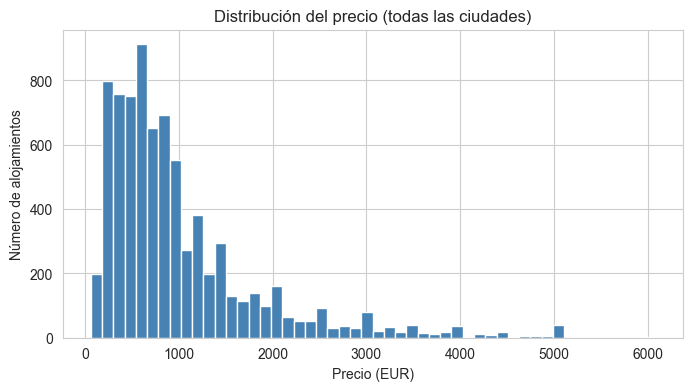

In [10]:
# Distribución del precio: histograma
# (price tiene nulos, se excluyen solo para este gráfico)
plt.figure(figsize=(8, 4))
plt.hist(df["price"].dropna(), bins=50, color="steelblue")
plt.title("Distribución del precio (todas las ciudades)")
plt.xlabel("Precio (EUR)")
plt.ylabel("Número de alojamientos")
plt.show()


El histograma muestra una fuerte asimetría a la derecha: la
mayoría de los precios se concentra en valores bajos/medios,
con una cola larga de alojamientos de precio muy alto (posibles
alojamientos de lujo o valores atípicos). Esto se tendrá en
cuenta más adelante al comparar precios entre ciudades.


In [11]:
# Alojamientos por ciudad (para dimensionar cada mercado)
df["city"].value_counts()


city
barcelona    2358
madrid       1703
mallorca     1318
girona       1242
sevilla       428
malaga        408
valencia      372
menorca       171
Name: count, dtype: int64

## 3. Pregunta de negocio 1 - Marketing y estrategia comercial

**¿Qué características de los alojamientos (servicios,
capacidad y ubicación) están más relacionadas con los precios
en cada ciudad?**


In [12]:
# Creamos una variable simple: número de servicios (amenities)
# contando los elementos separados por coma en amenities_list
df["n_amenities"] = df["amenities_list"].fillna("").apply(
    lambda texto: len(texto.split(",")) if texto != "" else 0
)

df[["amenities_list", "n_amenities"]].head()


,amenities_list,n_amenities
0,"TV,Internet,Wifi,Air conditioning,Elevator,Buz...",19
1,"TV,Internet,Wifi,Air conditioning,Kitchen,Free...",31
2,"TV,Internet,Wifi,Air conditioning,Wheelchair a...",34
3,"TV,Internet,Wifi,Kitchen,Breakfast,Elevator,Bu...",27
4,"Wifi,Pool,Free parking on premises,Breakfast,P...",43


In [13]:
# Variables de capacidad y servicios a comparar con el precio
variables_capacidad = [
    "price", "accommodates", "bathrooms", "bedrooms",
    "beds", "n_amenities",
]

# Correlación de cada variable con el precio (todas las ciudades)
correlacion_precio = df[variables_capacidad].corr()["price"]
correlacion_precio.sort_values(ascending=False)


price           1.000000
accommodates    0.619782
bedrooms        0.614192
beds            0.574849
bathrooms       0.522015
n_amenities     0.117062
Name: price, dtype: float64

`accommodates`, `bedrooms` y `bathrooms` son las variables con
mayor correlación con el precio (todas por encima de 0.5). El
número de servicios (`n_amenities`) tiene una relación mucho más
débil con el precio.


In [14]:
# La misma correlación, pero calculada ciudad por ciudad
correlacion_por_ciudad = df.groupby("city")[
    variables_capacidad
].corr()["price"].unstack()

correlacion_por_ciudad


,price,accommodates,bathrooms,bedrooms,beds,n_amenities
city,,,,,,
barcelona,1.0,0.613029,0.316701,0.571242,0.566943,0.196920
girona,1.0,0.581895,0.595634,0.608769,0.522611,0.065372
madrid,1.0,0.514633,0.241154,0.414087,0.441039,0.118889
malaga,1.0,0.506113,0.444875,0.522606,0.457276,0.077566
mallorca,1.0,0.589080,0.553851,0.589613,0.509307,0.066746
menorca,1.0,0.652807,0.668068,0.670744,0.514614,0.047897
sevilla,1.0,0.357063,0.190704,0.286160,0.300551,-0.082686
valencia,1.0,0.452975,0.303209,0.375561,0.446227,-0.031404


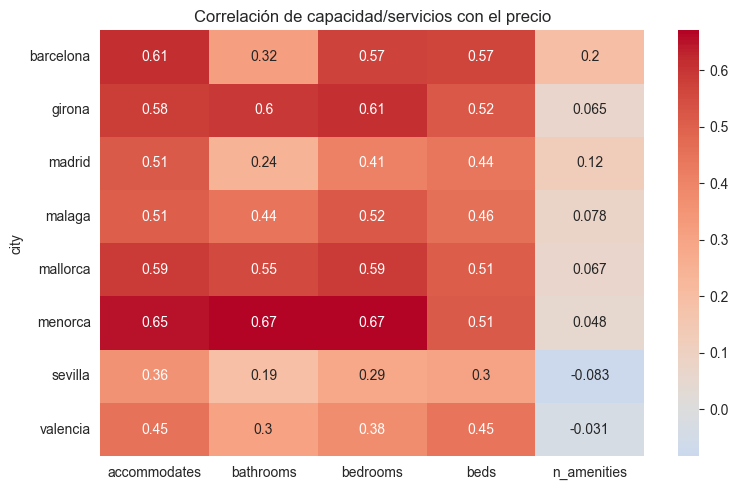

In [15]:
# Heatmap de la correlación con el precio, por ciudad
plt.figure(figsize=(8, 5))
sns.heatmap(
    correlacion_por_ciudad.drop(columns="price"),
    annot=True, cmap="coolwarm", center=0,
)
plt.title("Correlación de capacidad/servicios con el precio")
plt.tight_layout()
plt.show()


In [16]:
# Precio medio por ciudad y tipo de alojamiento (ubicación)
precio_ciudad_tipo = df.groupby(
    ["city", "room_type"]
)["price"].mean().round(2)

precio_ciudad_tipo


city       room_type      
barcelona  Entire home/apt    1277.68
           Hotel room         1293.64
           Private room        460.34
           Shared room         366.00
girona     Entire home/apt    1229.84
           Hotel room          545.00
           Private room        628.12
madrid     Entire home/apt     955.08
           Hotel room          870.00
           Private room        372.08
           Shared room         290.00
malaga     Entire home/apt     811.95
           Hotel room          703.33
           Private room        355.15
           Shared room         143.33
mallorca   Entire home/apt    1703.27
           Hotel room         1437.78
           Private room        741.47
           Shared room         437.50
menorca    Entire home/apt    1635.88
           Private room        543.33
sevilla    Entire home/apt    1053.09
           Hotel room          843.33
           Private room        579.76
           Shared room         120.00
valencia   Entire home/

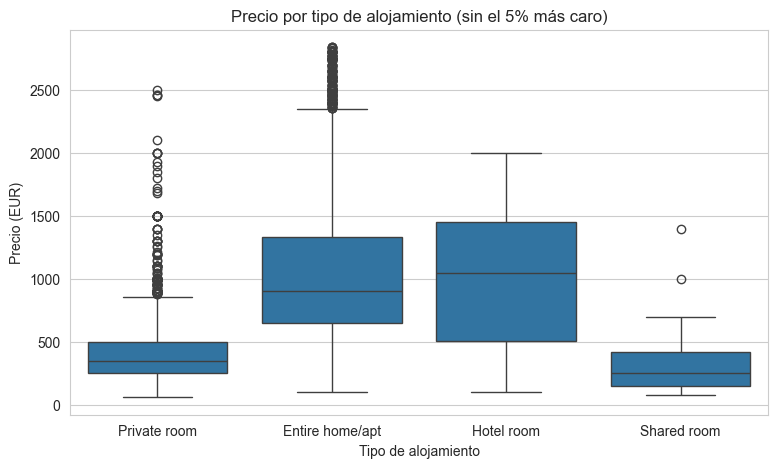

In [17]:
# Boxplot del precio por tipo de alojamiento (ubicación general)
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df[df["price"] < df["price"].quantile(0.95)],
    x="room_type", y="price",
)
plt.title("Precio por tipo de alojamiento (sin el 5% más caro)")
plt.xlabel("Tipo de alojamiento")
plt.ylabel("Precio (EUR)")
plt.show()


- `accommodates`, `bedrooms` y `bathrooms` son las variables de
  capacidad más relacionadas con el precio en la mayoría de
  ciudades; el número de servicios (`n_amenities`) pesa mucho
  menos.
- La fuerza de esta relación varía por ciudad (ver heatmap): no
  se puede asumir el mismo patrón para todas las ciudades.
- `room_type` (ubicación/tipo) también marca diferencias claras
  de precio: "Entire home/apt" es sistemáticamente más caro que
  "Private room" o "Shared room" en cada ciudad.


## 4. Pregunta de negocio 2 - Operaciones e inventario

**¿Cuál es el impacto de la reserva automática
(`is_instant_bookable`) en la disponibilidad media de cada
ciudad?**


In [18]:
# Comprobamos los valores posibles de is_instant_bookable
df["is_instant_bookable"].value_counts()


is_instant_bookable
VERDADERO    4439
FALSO        3561
Name: count, dtype: int64

In [19]:
# Disponibilidad media (30/60/90/365 días) según ciudad
# y si la reserva es automática (VERDADERO) o no (FALSO)
columnas_disp = [
    "availability_30", "availability_60",
    "availability_90", "availability_365",
]

disponibilidad_media = df.groupby(
    ["city", "is_instant_bookable"]
)[columnas_disp].mean().round(1)

disponibilidad_media


availability_30  availability_60  \
city      is_instant_bookable                                     
barcelona FALSO                           11.4             25.9   
          VERDADERO                       11.0             25.9   
girona    FALSO                           16.7             35.3   
          VERDADERO                       13.2             28.2   
madrid    FALSO                           10.5             23.2   
          VERDADERO                       10.9             25.9   
malaga    FALSO                           12.7             29.1   
          VERDADERO                       12.5             28.9   
mallorca  FALSO                           13.5             29.0   
          VERDADERO                       13.5             28.8   
menorca   FALSO                           15.7             32.1   
          VERDADERO                       13.4             28.4   
sevilla   FALSO                           13.0             28.9   
          VERDADERO                       14.7             32.1   
valencia  FALSO                           13.7             29.9   
          VERDADERO                       12.2             27.4   

                               availability_90  availability_365  
city      is_instant_bookable                                     
barcelona FALSO                           42.5             178.5  
          VERDADERO                       43.7             192.6  
girona    FALSO                           55.0             233.8  
          VERDADERO                       43.4             167.4  
madrid    FALSO                           37.8             156.1  
          VERDADERO                       43.1             172.0  
malaga    FALSO                           48.5             199.5  
          VERDADERO                       47.6             205.1  
mallorca  FALSO                           46.1             216.4  
          VERDADERO                       45.1             209.1  
menorca   FALSO                           49.1             214.7  
          VERDADERO                       44.6             178.6  
sevilla   FALSO                           47.1             187.2  
          VERDADERO                       51.7             203.0  
valencia  FALSO                           47.3             187.5  
          VERDADERO                       45.4             174.5

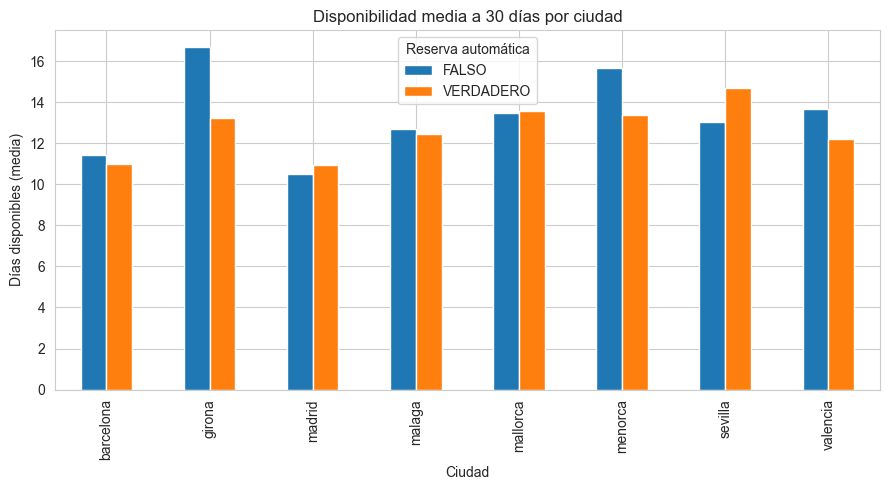

In [20]:
# Gráfico: disponibilidad media a 30 días, por ciudad,
# separando reserva automática (VERDADERO) vs manual (FALSO)
tabla_30 = df.groupby(
    ["city", "is_instant_bookable"]
)["availability_30"].mean().unstack()

tabla_30.plot(kind="bar", figsize=(9, 5))
plt.title("Disponibilidad media a 30 días por ciudad")
plt.xlabel("Ciudad")
plt.ylabel("Días disponibles (media)")
plt.legend(title="Reserva automática")
plt.tight_layout()
plt.show()


In [21]:
# Diferencia (VERDADERO - FALSO) en disponibilidad a 30 días,
# ciudad por ciudad, para ver dónde el efecto es mayor
diferencia_30 = (
    tabla_30["VERDADERO"] - tabla_30["FALSO"]
).sort_values(ascending=False)

diferencia_30


city
sevilla      1.634468
madrid       0.403124
mallorca     0.063384
malaga      -0.229569
barcelona   -0.427469
valencia    -1.460685
menorca     -2.301321
girona      -3.440476
dtype: float64

- El efecto de la reserva automática sobre la disponibilidad
  media **no es uniforme**: en algunas ciudades (p. ej. Girona,
  Menorca) los alojamientos con reserva automática muestran
  menor disponibilidad media a 30 días que los que no la
  tienen; en otras (p. ej. Sevilla) ocurre lo contrario.
- Antes de sacar conclusiones generales para todo el mercado,
  conviene mirar ciudad por ciudad, ya que la tabla anterior
  muestra diferencias de signo opuesto según la ciudad.


## 5. Pregunta de negocio 3 - Experiencia del cliente

**¿Qué aspectos (precisión, limpieza, check-in o comunicación)
muestran mayores diferencias entre los alojamientos mejor y
peor valorados en la valoración global
(`review_scores_rating`)?**


In [22]:
# Solo alojamientos con valoración global (excluimos sin reviews)
df_valorados = df.dropna(subset=["review_scores_rating"]).copy()

print("Alojamientos con valoración:", len(df_valorados))


Alojamientos con valoración: 6304


In [23]:
# Definimos "mejor valorados" y "peor valorados" con cuartiles
# de review_scores_rating (25% superior vs 25% inferior)
q25 = df_valorados["review_scores_rating"].quantile(0.25)
q75 = df_valorados["review_scores_rating"].quantile(0.75)

peor_valorados = df_valorados[
    df_valorados["review_scores_rating"] <= q25
]
mejor_valorados = df_valorados[
    df_valorados["review_scores_rating"] >= q75
]

print("Peor valorados:", len(peor_valorados))
print("Mejor valorados:", len(mejor_valorados))


Peor valorados: 1634
Mejor valorados: 1755


In [24]:
# Aspectos de la experiencia a comparar entre los dos grupos
aspectos = [
    "review_scores_accuracy", "review_scores_cleanliness",
    "review_scores_checkin", "review_scores_communication",
]

comparacion = pd.DataFrame({
    "peor_valorados": peor_valorados[aspectos].mean(),
    "mejor_valorados": mejor_valorados[aspectos].mean(),
})
comparacion["diferencia"] = (
    comparacion["mejor_valorados"] - comparacion["peor_valorados"]
)
comparacion.sort_values("diferencia", ascending=False)


,peor_valorados,mejor_valorados,diferencia
review_scores_cleanliness,84.411765,98.329532,13.917768
review_scores_accuracy,85.910209,99.030787,13.120578
review_scores_communication,90.122699,99.253136,9.130436
review_scores_checkin,90.300983,99.009731,8.708748


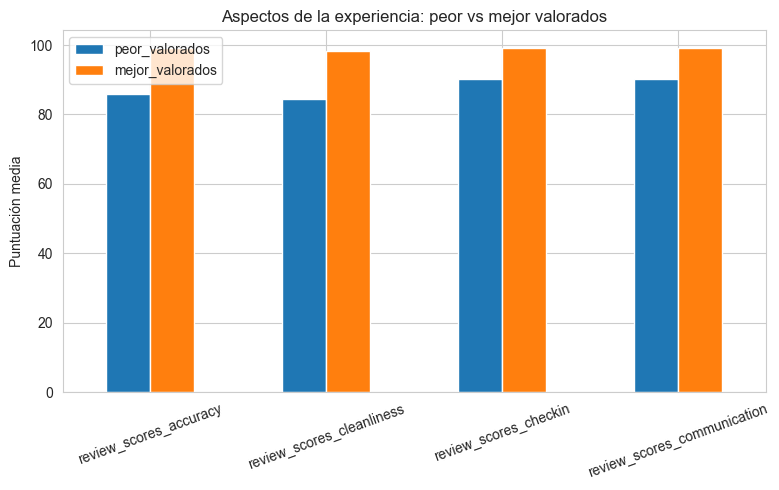

In [25]:
# Gráfico de barras comparando cada aspecto entre los dos grupos
comparacion[["peor_valorados", "mejor_valorados"]].plot(
    kind="bar", figsize=(8, 5)
)
plt.title("Aspectos de la experiencia: peor vs mejor valorados")
plt.ylabel("Puntuación media")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [26]:
# Correlación de cada aspecto con la valoración global
# (usando todos los alojamientos valorados, no solo los extremos)
correlacion_aspectos = df_valorados[
    ["review_scores_rating"] + aspectos
].corr()["review_scores_rating"].drop("review_scores_rating")

correlacion_aspectos.sort_values(ascending=False)


review_scores_accuracy         0.733512
review_scores_cleanliness      0.685092
review_scores_communication    0.615400
review_scores_checkin          0.568017
Name: review_scores_rating, dtype: float64

- El aspecto con **mayor diferencia** entre alojamientos peor y
  mejor valorados es `review_scores_cleanliness` (limpieza),
  seguido de `review_scores_accuracy` (precisión de los
  detalles).
- `review_scores_checkin` (entrada) es el que menos diferencia
  muestra entre los dos grupos: incluso los alojamientos peor
  valorados globalmente mantienen un check-in relativamente
  bueno.
- Esto es coherente con las correlaciones: limpieza y precisión
  son los aspectos más ligados a la valoración global, mientras
  que check-in tiene la relación más débil de los cuatro.


## 6. Conclusiones 

- **Marketing:** capacidad (`accommodates`, `bedrooms`,
  `bathrooms`) explica el precio mejor que el número de
  servicios; el efecto varía por ciudad.
- **Operaciones:** la reserva automática no tiene un efecto
  único sobre la disponibilidad; el signo cambia según la
  ciudad, por lo que no se recomienda una política uniforme.
- **Experiencia cliente:** limpieza y precisión son los
  aspectos que más diferencian a los alojamientos mejor y peor
  valorados; check-in es el más estable entre ambos grupos.


